# Statistical Models

In this notebook, I apply statistical forecasting models to the cleaned sales time series from Week 1.
The goal is to train statistical models on data from **2013-01-01 to 2013-12-31** and evaluate their forecasts on data from **2014-01-01 to 2014-03-31**.

# 1. Environment Setup

In [2]:
# os - for working with file paths
import os

# pandas - for working with tabular data
import pandas as pd

# numpy - for numerical operations
import numpy as np

# matplotlib - for plotting charts
import matplotlib.pyplot as plt

# seaborn - for improved chart styling
import seaborn as sns

# statsmodels - for time series analysis and forecasting
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# prophet - for forecasting
from prophet import Prophet

# scikit-learn - for evaluation metrics and feature analysis
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

# warnings - to hide unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


# 2. Data Loading

In [3]:
# Load the cleaned main time series from Week 1
timeseries = pd.read_csv("../../data/timeseries_cleaned.csv")

In [4]:
# Display the first rows of the cleaned time series
timeseries.head()

,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0


In [5]:
timeseries.shape

(452, 2)

# 3. Data Preparation and Exploration

In [6]:
# Check basic information about the cleaned time series
timeseries.info()

<class 'pandas.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        452 non-null    str    
 1   unit_sales  452 non-null    float64
dtypes: float64(1), str(1)
memory usage: 7.2 KB


In [7]:
# Convert the date column to datetime format
timeseries["date"] = pd.to_datetime(timeseries["date"])

In [8]:
# Check data types after datetime conversion
print(timeseries.dtypes)

date          datetime64[us]
unit_sales           float64
dtype: object


In [9]:
# Check the date range of the cleaned time series
print("Date range:", timeseries["date"].min(), "to", timeseries["date"].max())

Date range: 2013-01-02 00:00:00 to 2014-03-31 00:00:00


In [10]:
# Set the date column as the index for time series modeling
timeseries = timeseries.set_index("date")

timeseries.head()

,unit_sales
date,
2013-01-02,582.0
2013-01-03,310.0
2013-01-04,338.0
2013-01-05,654.0
2013-01-06,979.0


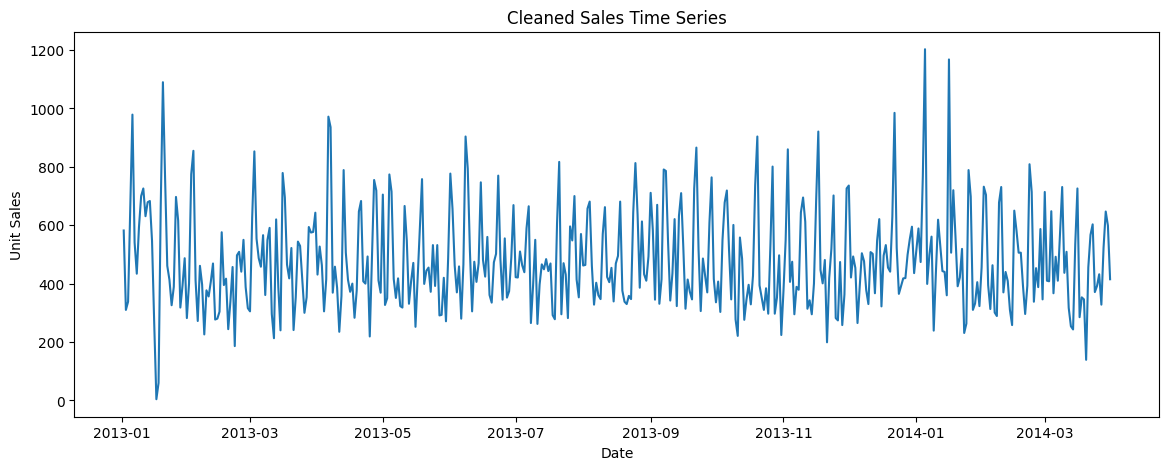

In [11]:
# Plot the cleaned sales time series
plt.figure(figsize=(14, 5))
plt.plot(timeseries.index, timeseries["unit_sales"])
plt.title("Cleaned Sales Time Series")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.show()

# 4. Time Series Decomposition

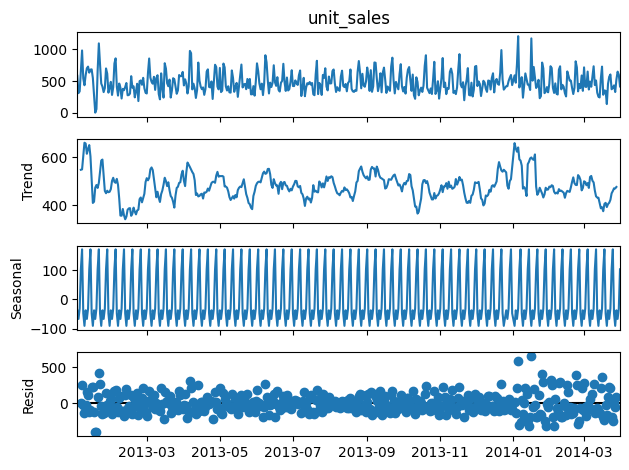

In [12]:
# Decompose the time series into trend, seasonality, and residuals
decomposition = seasonal_decompose(timeseries["unit_sales"], model="additive", period=7)

# Plot the decomposition components
decomposition.plot()
plt.show()

# 5. Stationarity Check

In [13]:
# Perform the Augmented Dickey-Fuller test
adf_result = adfuller(timeseries["unit_sales"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -5.092260058040776
p-value: 1.453017741687818e-05
Critical Values:
   1%: -3.445542818501549
   5%: -2.868238133603207
   10%: -2.5703378690483176


The ADF test suggests that the time series is likely stationary, because the p-value is below 0.05. This means we can proceed with statistical modeling without applying an additional differencing step at this stage.

# 6. Autocorrelation Analysis

<Figure size 1000x400 with 0 Axes>

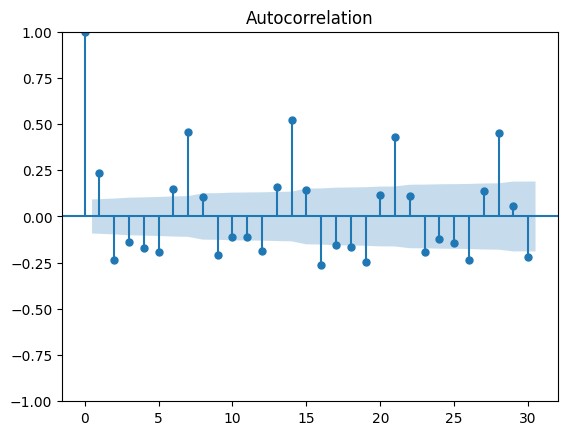

In [14]:
# Plot the autocorrelation function (ACF)
plt.figure(figsize=(10, 4))
plot_acf(timeseries["unit_sales"], lags=30)
plt.show()

<Figure size 1000x400 with 0 Axes>

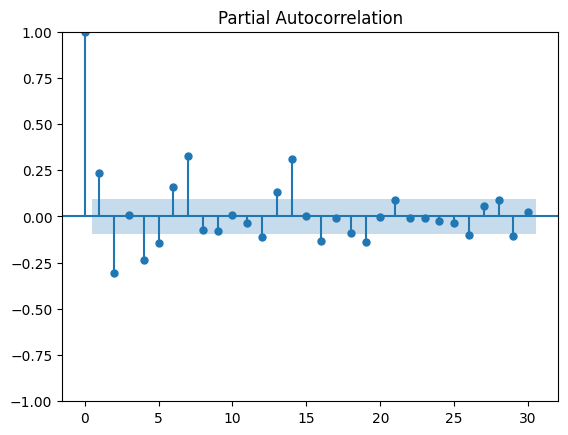

In [15]:
# Plot the partial autocorrelation function (PACF)
plt.figure(figsize=(10, 4))
plot_pacf(timeseries["unit_sales"], lags=30)
plt.show()

The ACF and PACF plots show several significant spikes, including a visible repeating weekly pattern. This suggests that autoregressive and seasonal components may be useful in the statistical forecasting models.

# 7. Exploratory Analysis for Statistical Modelling

This section explores a few additional patterns in the sales series that may help interpret the behavior of the data before fitting statistical forecasting models.

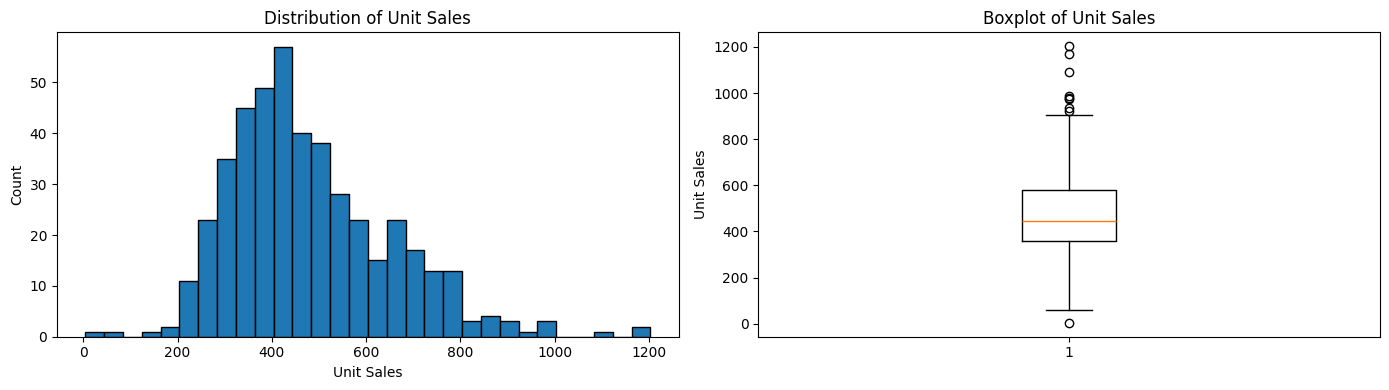

In [16]:
# Plot the distribution and boxplot of unit sales
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.hist(timeseries["unit_sales"], bins=30, edgecolor="black")
plt.title("Distribution of Unit Sales")
plt.xlabel("Unit Sales")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.boxplot(timeseries["unit_sales"])
plt.title("Boxplot of Unit Sales")
plt.ylabel("Unit Sales")

plt.tight_layout()
plt.show()

The sales distribution is right-skewed, with most observations concentrated in the mid-range and a smaller number of high-sales days. The boxplot also shows several upper outliers, which suggests that occasional sales spikes are present in the series.

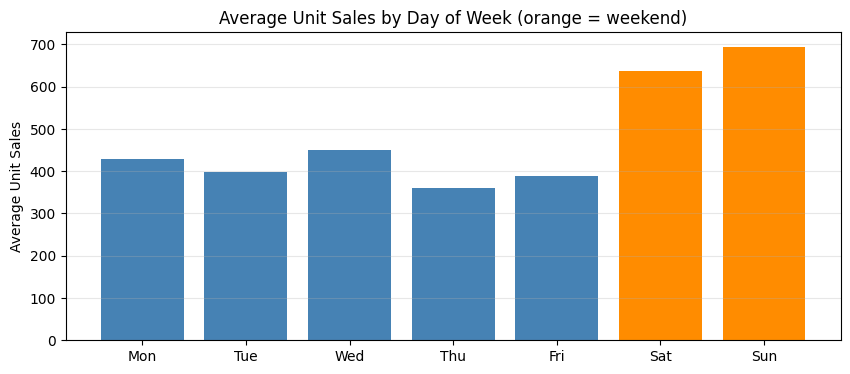

In [17]:
# Create a day-of-week column for exploratory analysis
timeseries["day_of_week"] = timeseries.index.dayofweek

# Calculate average sales by day of week
avg_sales_by_day = timeseries.groupby("day_of_week")["unit_sales"].mean()

# Define day labels and colors
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
bar_colors = ["steelblue", "steelblue", "steelblue", "steelblue", "steelblue", "darkorange", "darkorange"]

# Plot average sales by day of week
plt.figure(figsize=(10, 4))
plt.bar(day_labels, avg_sales_by_day.values, color=bar_colors)
plt.title("Average Unit Sales by Day of Week (orange = weekend)")
plt.xlabel("")
plt.ylabel("Average Unit Sales")
plt.grid(axis="y", alpha=0.3)
plt.show()

Average sales vary noticeably across the week. The highest values appear on Saturday and Sunday, which suggests a strong weekend effect in the sales series.

Next, I check whether oil prices show a visible relationship with sales over time.

In [18]:
# Load the processed oil dataset for exploratory analysis
oil = pd.read_csv("../../data/processed/oil_interpolated.csv")

# Convert the oil date column to datetime
oil["date"] = pd.to_datetime(oil["date"])

In [19]:
# Merge the sales series with oil prices for exploratory analysis
sales_oil = timeseries.reset_index().merge(
    oil[["date", "oil_price_interpolated"]],
    on="date",
    how="left"
)

# Fill missing oil values after the merge
sales_oil["oil_price_interpolated"] = sales_oil["oil_price_interpolated"].ffill()

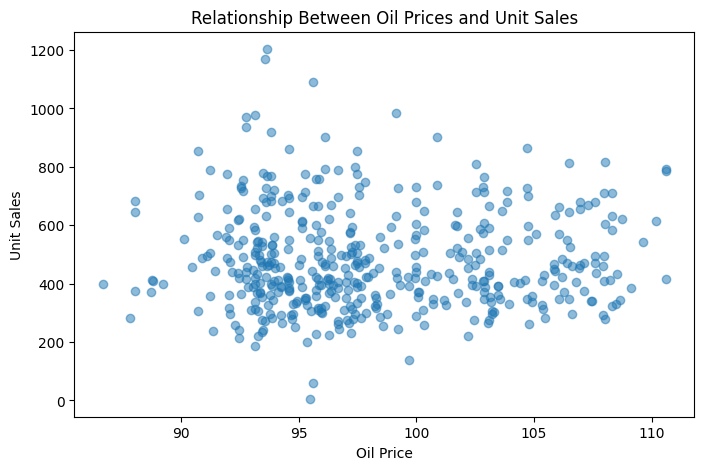

In [20]:
# Plot the relationship between oil prices and unit sales
plt.figure(figsize=(8, 5))
plt.scatter(
    sales_oil["oil_price_interpolated"],
    sales_oil["unit_sales"],
    alpha=0.5
)
plt.title("Relationship Between Oil Prices and Unit Sales")
plt.xlabel("Oil Price")
plt.ylabel("Unit Sales")
plt.show()

The scatter plot does not show a strong linear relationship between oil prices and unit sales. Any effect of oil prices on sales is likely to be weak, indirect, or mixed with other factors.

In [21]:
# Check correlations between numeric variables
sales_oil[["unit_sales", "oil_price_interpolated"]].corr()

,unit_sales,oil_price_interpolated
unit_sales,1.000000,0.004289
oil_price_interpolated,0.004289,1.000000


# 8. Train-Test Split

In [22]:
# Split the time series into train and test sets using the official project periods
train = timeseries.loc["2013-01-01":"2013-12-31"].copy()
test = timeseries.loc["2014-01-01":"2014-03-31"].copy()

In [23]:
# Check the shape and date range of the train and test sets
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("Train period:", train.index.min(), "to", train.index.max())
print("Test period:", test.index.min(), "to", test.index.max())

Train shape: (363, 2)
Test shape: (89, 2)
Train period: 2013-01-02 00:00:00 to 2013-12-31 00:00:00
Test period: 2014-01-02 00:00:00 to 2014-03-31 00:00:00


The test period contains 89 days, which matches the project evaluation window

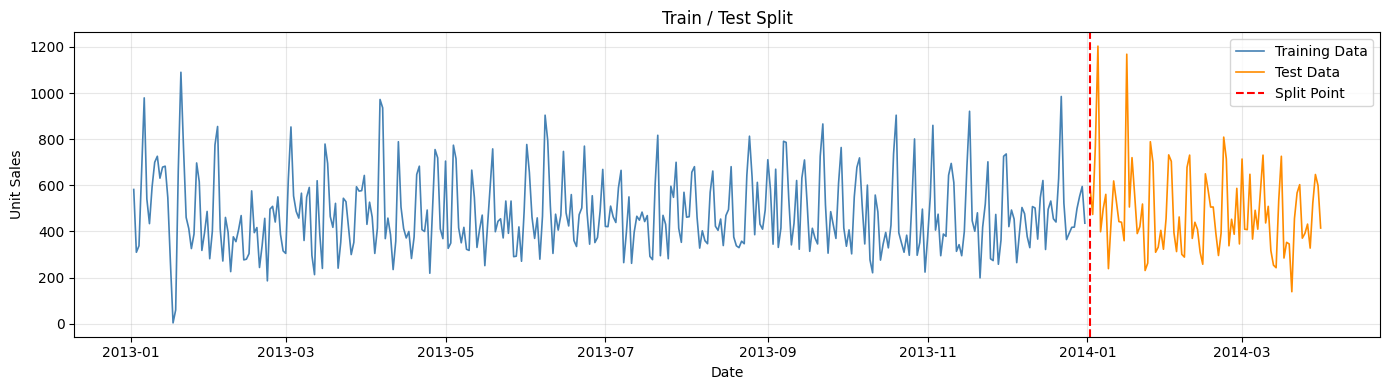

In [24]:
# Visualize the train-test split
plt.figure(figsize=(14, 4))
plt.plot(train.index, train["unit_sales"], label="Training Data", color="steelblue", linewidth=1.2)
plt.plot(test.index, test["unit_sales"], label="Test Data", color="darkorange", linewidth=1.2)
plt.axvline(x=test.index.min(), color="red", linestyle="--", linewidth=1.5, label="Split Point")
plt.title("Train / Test Split")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9. Check Stationarity on the Training Series

The earlier stationarity and autocorrelation checks were used for general exploration of the full series. At this stage, the same diagnostics are repeated on the training period only, so that the model choice is based strictly on the training data.

In [25]:
# Define a helper function to check stationarity with the ADF test
def check_stationarity(series, name):
    result = adfuller(series.dropna())
    p_value = result[1]

    print("ADF Test —", name)
    print("  p-value:", round(p_value, 4))

    if p_value <= 0.05:
        print("  Result: Stationary — ready for ARIMA/SARIMAX")
    else:
        print("  Result: Not stationary — differencing may be needed")

    print()

# Test the training sales series
check_stationarity(train["unit_sales"], "unit_sales (training)")

ADF Test — unit_sales (training)
  p-value: 0.0007
  Result: Stationary — ready for ARIMA/SARIMAX



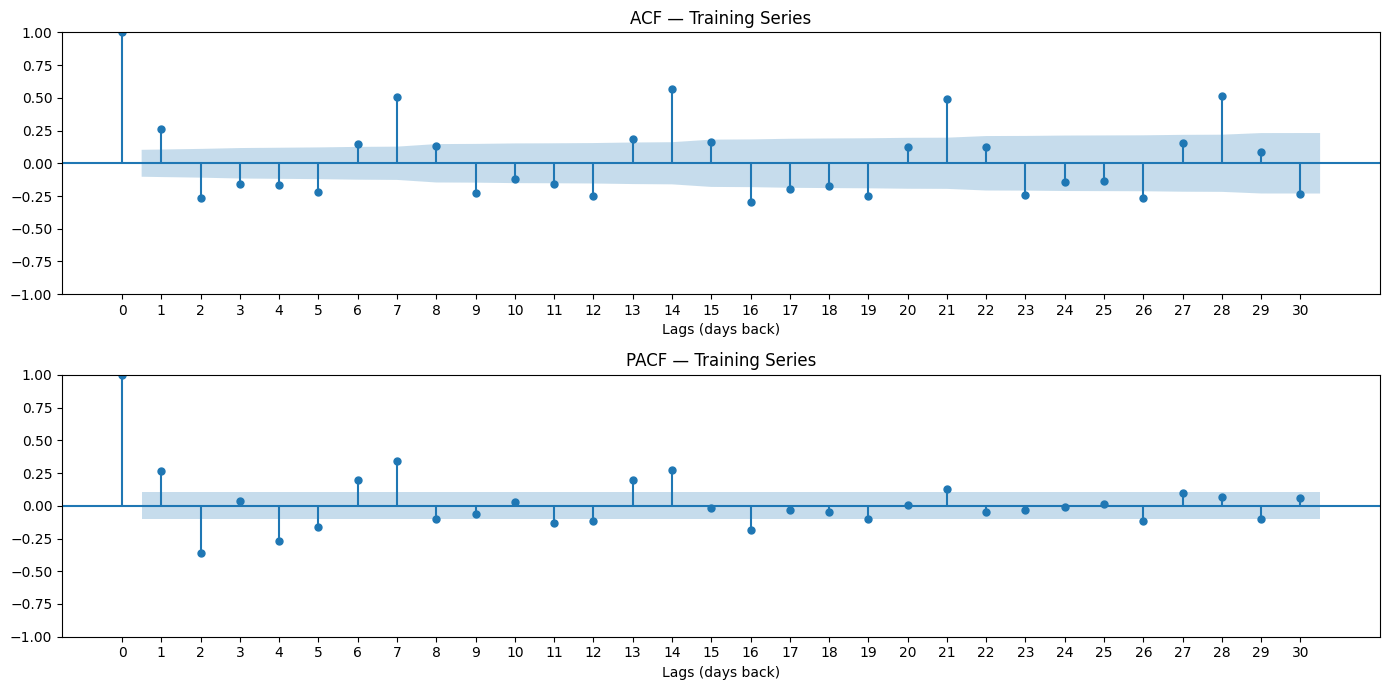

In [26]:
# Plot ACF and PACF for the training series with every lag shown on the x-axis
series = train["unit_sales"].dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# ACF
plot_acf(series, lags=30, ax=axes[0])
axes[0].set_title("ACF — Training Series")
axes[0].set_xlabel("Lags (days back)")
axes[0].set_xticks(range(0, 31, 1))

# PACF
plot_pacf(series, lags=30, ax=axes[1])
axes[1].set_title("PACF — Training Series")
axes[1].set_xlabel("Lags (days back)")
axes[1].set_xticks(range(0, 31, 1))

plt.tight_layout()
plt.show()

The ACF and PACF plots show that the training series still contains meaningful autocorrelation. Several spikes remain outside the confidence bands, especially at lag 1 and around lag 7. This suggests that past values are informative for forecasting and that a weekly seasonal component should be considered in the SARIMAX model.

How to read these plots:

- PACF helps identify the autoregressive part of the model.
- ACF helps identify the moving average part of the model.
- A visible spike around lag 7 suggests a weekly seasonal pattern and supports the use of a seasonal component.

# 10. Prepare Exogenous Features for SARIMAX

In [27]:
# Prepare the base dataframe for SARIMAX exogenous features
sarimax_df = pd.read_csv("../../data/processed/feature_engineered_timeseries.csv")

# Convert the date column to datetime
sarimax_df["date"] = pd.to_datetime(sarimax_df["date"])

In [28]:
# Select the exogenous features used in the SARIMAX model
exog_cols = [
    "oil_price_interpolated",
    "is_national_holiday",
    "is_regional_holiday",
    "is_local_holiday",
    "is_weekend"
]

In [29]:
# Split the feature-based dataframe into train and test periods
train_exog_df = sarimax_df[(sarimax_df["date"] >= "2013-01-01") & (sarimax_df["date"] <= "2013-12-31")].copy()
test_exog_df = sarimax_df[(sarimax_df["date"] >= "2014-01-01") & (sarimax_df["date"] <= "2014-03-31")].copy()

In [30]:
# Keep only the selected exogenous columns
exog_train = train_exog_df[exog_cols].copy()
exog_test = test_exog_df[exog_cols].copy()

In [31]:
# Check the shape of the exogenous feature sets
print("Training exog shape:", exog_train.shape)
print("Test exog shape:", exog_test.shape)

print("\nFirst 5 rows of training exogenous features:")
display(exog_train.head())

Training exog shape: (335, 5)
Test exog shape: (89, 5)

First 5 rows of training exogenous features:


,oil_price_interpolated,is_national_holiday,is_regional_holiday,is_local_holiday,is_weekend
0,97.46,0,0,0,0
1,97.46,0,0,0,1
2,97.46,0,0,0,1
3,96.21,0,0,0,0
4,96.68,0,0,0,0


In [32]:
# Verify that the target series and exogenous features have matching lengths
print("Train target length:", len(train))
print("Train exog length:", len(exog_train))

print("Test target length:", len(test))
print("Test exog length:", len(exog_test))

Train target length: 363
Train exog length: 335
Test target length: 89
Test exog length: 89


The exogenous feature dataframe does not align with the target training series, because it was created after dropping rows with missing lag and rolling features. For SARIMAX, the exogenous variables must match the target series row by row, so a separate aligned exogenous dataframe will be prepared next.

In [33]:
# Build an aligned exogenous dataframe directly from the cleaned time series dates
sarimax_exog_df = timeseries.reset_index()[["date"]].copy()

# Ensure the date column is in datetime format
sarimax_exog_df["date"] = pd.to_datetime(sarimax_exog_df["date"])

# Add weekend flag
sarimax_exog_df["is_weekend"] = sarimax_exog_df["date"].dt.dayofweek.isin([5, 6]).astype(int)

In [34]:
# Load external datasets for aligned SARIMAX exogenous features
oil = pd.read_csv("../../data/processed/oil_interpolated.csv")
holidays = pd.read_csv("../../data/raw/holidays.csv")

# Convert date columns to datetime
oil["date"] = pd.to_datetime(oil["date"])
holidays["date"] = pd.to_datetime(holidays["date"])

In [35]:
# Merge oil prices into the aligned SARIMAX exogenous dataframe
sarimax_exog_df = sarimax_exog_df.merge(
    oil[["date", "oil_price_interpolated"]],
    on="date",
    how="left"
)

# Fill missing oil values after the merge
sarimax_exog_df["oil_price_interpolated"] = sarimax_exog_df["oil_price_interpolated"].ffill()

In [36]:
# Create aligned holiday flags directly in the SARIMAX exogenous dataframe
sarimax_exog_df["is_national_holiday"] = sarimax_exog_df["date"].isin(
    holidays.loc[holidays["locale"] == "National", "date"]
).astype(int)

sarimax_exog_df["is_regional_holiday"] = sarimax_exog_df["date"].isin(
    holidays.loc[holidays["locale"] == "Regional", "date"]
).astype(int)

sarimax_exog_df["is_local_holiday"] = sarimax_exog_df["date"].isin(
    holidays.loc[holidays["locale"] == "Local", "date"]
).astype(int)

In [37]:
# Display the first rows of the aligned SARIMAX exogenous dataframe
sarimax_exog_df.head()

,date,is_weekend,oil_price_interpolated,is_national_holiday,is_regional_holiday,is_local_holiday
0,2013-01-02,0,93.14,0,0,0
1,2013-01-03,0,92.97,0,0,0
2,2013-01-04,0,93.12,0,0,0
3,2013-01-05,1,93.12,1,0,0
4,2013-01-06,1,93.12,0,0,0


In [38]:
# Select the aligned exogenous columns for SARIMAX
exog_cols = [
    "oil_price_interpolated",
    "is_national_holiday",
    "is_regional_holiday",
    "is_local_holiday",
    "is_weekend"
]

In [39]:
# Split the aligned SARIMAX exogenous dataframe into train and test sets
exog_train = sarimax_exog_df[
    (sarimax_exog_df["date"] >= "2013-01-01") & (sarimax_exog_df["date"] <= "2013-12-31")
][exog_cols].copy()

exog_test = sarimax_exog_df[
    (sarimax_exog_df["date"] >= "2014-01-01") & (sarimax_exog_df["date"] <= "2014-03-31")
][exog_cols].copy()

In [40]:
# Verify that the aligned exogenous features now match the target series lengths
print("Train target length:", len(train))
print("Train exog length:", len(exog_train))

print("Test target length:", len(test))
print("Test exog length:", len(exog_test))

Train target length: 363
Train exog length: 363
Test target length: 89
Test exog length: 89


# 11. Model 1 — SARIMAX with Exogenous Features

In this section, I train the first statistical forecasting model using the training period and evaluate its predictions on the test period.

In [41]:
# Align the exogenous feature indices with the target series indices
exog_train.index = train.index
exog_test.index = test.index

In [42]:
# Train the first SARIMAX model with exogenous features
model_1 = SARIMAX(
    train["unit_sales"],
    exog=exog_train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 7)
)

model_1_fit = model_1.fit(disp=False)

In [43]:
# Display the summary of the fitted SARIMAX model
print(model_1_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                        unit_sales   No. Observations:                  363
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -2231.682
Date:                           Sun, 26 Apr 2026   AIC                           4483.364
Time:                                   22:10:23   BIC                           4522.308
Sample:                                        0   HQIC                          4498.844
                                           - 363                                         
Covariance Type:                             opg                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
oil_price_interpolated     4.1435      0.230     18.051      0.000       3.694       4.593
is_nati

In [44]:
# Generate out-of-sample forecasts for the full test period using exogenous features
forecast_1 = model_1_fit.forecast(steps=len(test), exog=exog_test)

In [45]:
# Align the forecast index with the test period dates
forecast_1.index = test.index

In [46]:
# Show forecast summary before plotting
print(f"Forecast generated for {len(forecast_1)} days.\n")

print("First 5 predictions:")
print(forecast_1.head())

Forecast generated for 89 days.

First 5 predictions:
date
2014-01-02    347.304981
2014-01-03    426.053871
2014-01-04    593.032438
2014-01-05    614.975435
2014-01-06    342.316144
Name: predicted_mean, dtype: float64


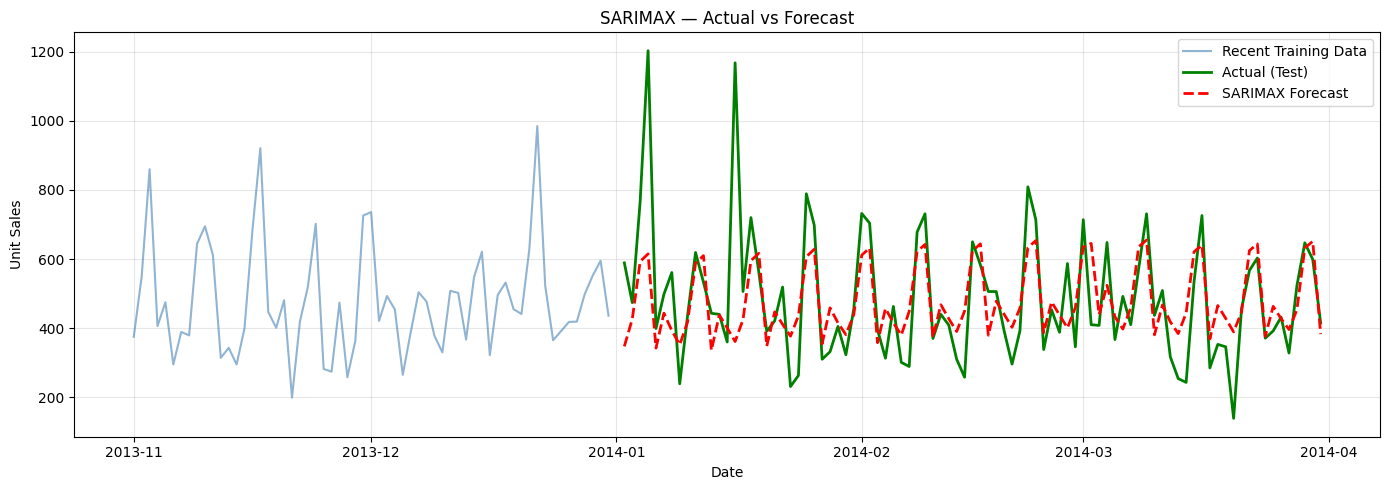

In [47]:
# Plot recent training data, actual test values, and SARIMAX forecast
plt.figure(figsize=(14, 5))

plt.plot(
    train.index[-60:],
    train["unit_sales"].iloc[-60:],
    label="Recent Training Data",
    color="steelblue",
    linewidth=1.5,
    alpha=0.6
)

plt.plot(
    test.index,
    test["unit_sales"],
    label="Actual (Test)",
    color="green",
    linewidth=2
)

plt.plot(
    forecast_1.index,
    forecast_1.values,
    label="SARIMAX Forecast",
    color="red",
    linewidth=2,
    linestyle="--"
)

plt.title("SARIMAX — Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
# Calculate evaluation metrics for the first SARIMAX model
mae_1 = mean_absolute_error(test["unit_sales"], forecast_1)
rmse_1 = mean_squared_error(test["unit_sales"], forecast_1) ** 0.5
r2_1 = r2_score(test["unit_sales"], forecast_1)
mape_1 = mean_absolute_percentage_error(test["unit_sales"], forecast_1)

print("SARIMAX Model — Evaluation Metrics:\n")

print(f"MAE   (Mean Absolute Error)      : {mae_1:.2f} units")
print("  -> Average absolute difference between forecast and actual\n")

print(f"RMSE  (Root Mean Squared Error) : {rmse_1:.2f} units")
print("  -> Like MAE but penalises large errors more heavily\n")

print(f"MAPE  (Mean Absolute % Error)   : {mape_1 * 100:.2f} %")
print("  -> Average percentage error\n")

print(f"R²    (Coefficient of Determination): {r2_1:.3f}")
print("  -> How much variance the model explains")

SARIMAX Model — Evaluation Metrics:

MAE   (Mean Absolute Error)      : 95.66 units
  -> Average absolute difference between forecast and actual

RMSE  (Root Mean Squared Error) : 144.82 units
  -> Like MAE but penalises large errors more heavily

MAPE  (Mean Absolute % Error)   : 21.97 %
  -> Average percentage error

R²    (Coefficient of Determination): 0.383
  -> How much variance the model explains


The SARIMAX model captures the recurring weekly pattern reasonably well, but it struggles with large spikes in the sales series. Overall, the model provides a useful baseline forecast, although there is still room for improvement with additional statistical approaches.

# 12. Model 2 — Holt-Winters (Triple Exponential Smoothing)

Holt-Winters is a statistical forecasting method that models a time series using level, trend, and seasonality. Unlike SARIMAX, it does not use external variables such as oil prices or holiday flags. It only learns patterns from the target sales series itself.

In [49]:
# Holt-Winters requires a clean series with no NaN values and the seasonal_periods must match the actual cycle in the data

# Our data is daily with a strong weekly cycle -> seasonal_periods=7

print("Fitting Holt-Winters Additive model...")
hw_add = ExponentialSmoothing(
    train["unit_sales"],
    trend="add",
    seasonal="add",
    seasonal_periods=7
)
hw_add_fit = hw_add.fit(optimized=True)

print("Fitting Holt-Winters Multiplicative model...")
hw_mul = ExponentialSmoothing(
    train["unit_sales"],
    trend="add",
    seasonal="mul",
    seasonal_periods=7
)
hw_mul_fit = hw_mul.fit(optimized=True)

print()
print("Both models fitted successfully!")
print()

print("Additive model parameters chosen automatically:")
print("  Alpha (level)   :", round(hw_add_fit.params["smoothing_level"], 4))
print("  Beta (trend)    :", round(hw_add_fit.params["smoothing_trend"], 4))
print("  Gamma (seasonal):", round(hw_add_fit.params["smoothing_seasonal"], 4))
print()

print("Multiplicative model parameters chosen automatically:")
print("  Alpha (level)   :", round(hw_mul_fit.params["smoothing_level"], 4))
print("  Beta (trend)    :", round(hw_mul_fit.params["smoothing_trend"], 4))
print("  Gamma (seasonal):", round(hw_mul_fit.params["smoothing_seasonal"], 4))

Fitting Holt-Winters Additive model...
Fitting Holt-Winters Multiplicative model...

Both models fitted successfully!

Additive model parameters chosen automatically:
  Alpha (level)   : 0.0
  Beta (trend)    : 0.0
  Gamma (seasonal): 0.0

Multiplicative model parameters chosen automatically:
  Alpha (level)   : 0.0
  Beta (trend)    : 0.0
  Gamma (seasonal): 0.0


The optimized smoothing parameters are extremely close to zero for both Holt-Winters variants. This suggests that the model relies mostly on the stable structure already estimated from the training series, with only minimal updating of level, trend, and seasonality over time.

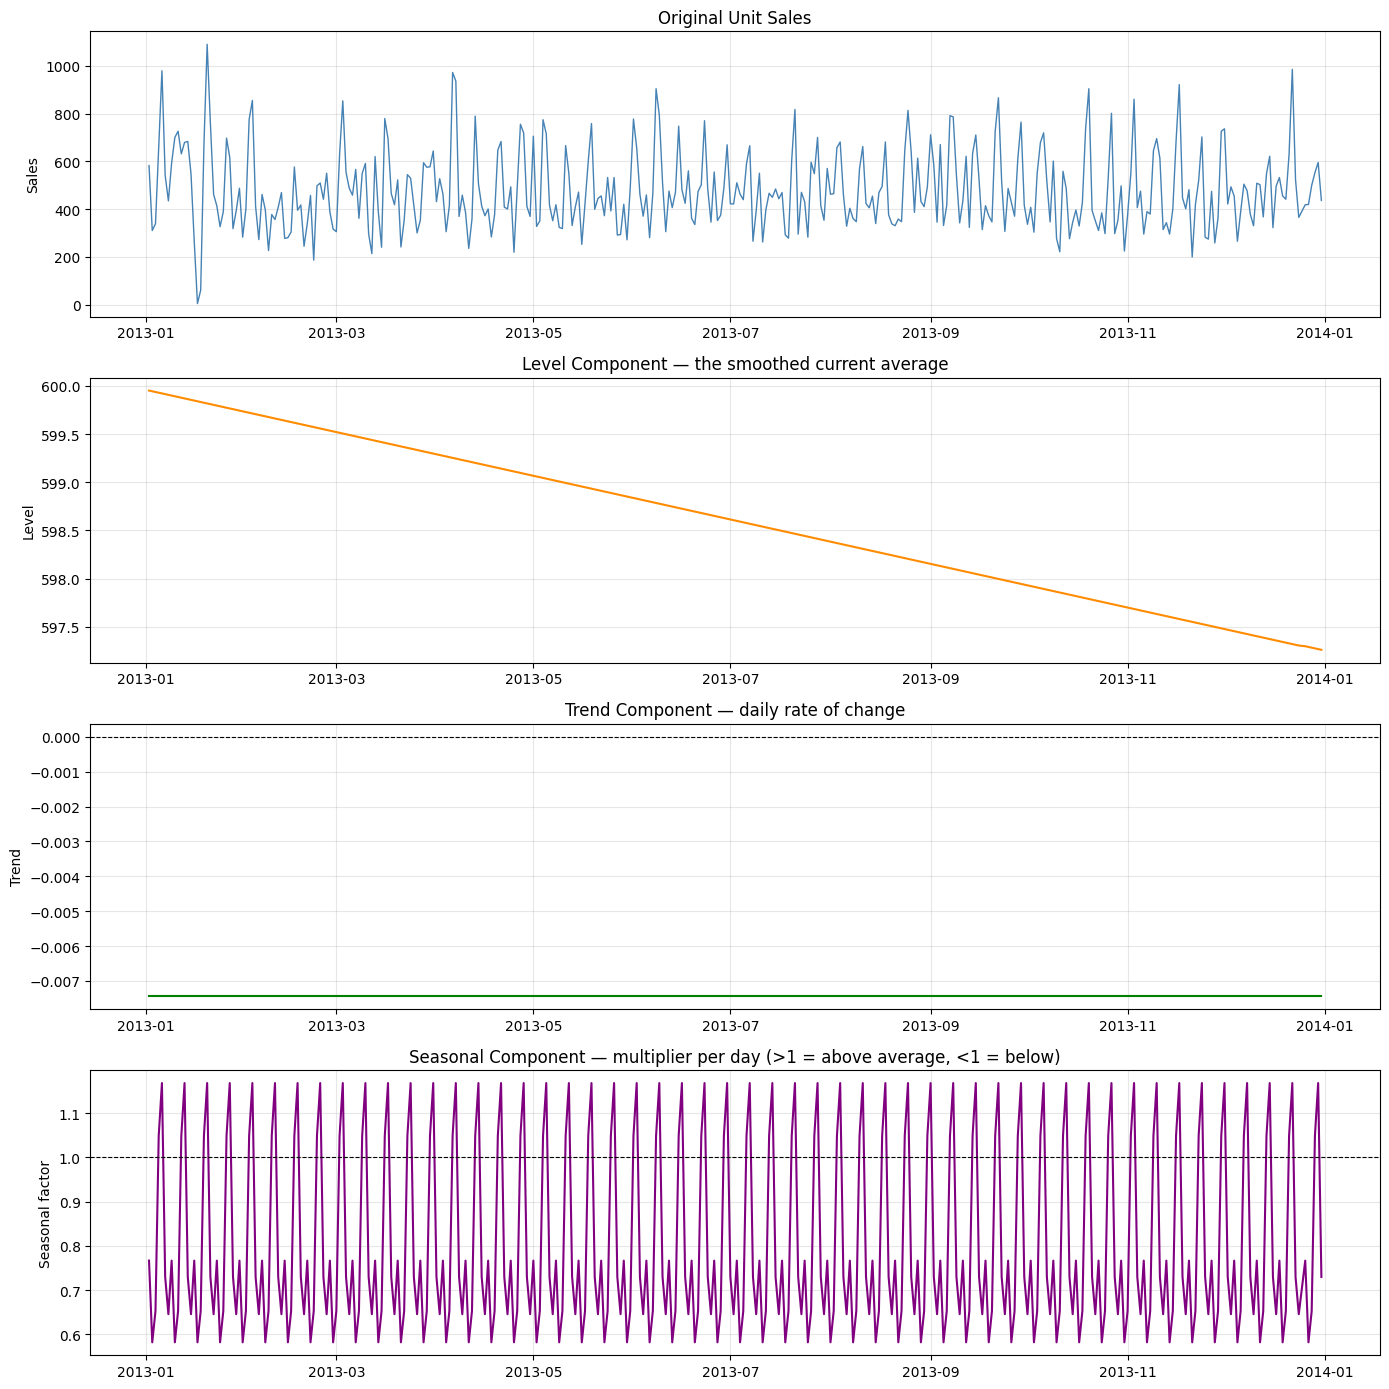

In [50]:
# Visualise the three internal components learned by the multiplicative model

fig, axes = plt.subplots(4, 1, figsize=(14, 14))

# 1. Original sales series
axes[0].plot(train.index, train["unit_sales"], color="steelblue", linewidth=1)
axes[0].set_title("Original Unit Sales")
axes[0].set_ylabel("Sales")
axes[0].grid(True, alpha=0.3)

# 2. Level component
axes[1].plot(train.index, hw_mul_fit.level, color="darkorange", linewidth=1.5)
axes[1].set_title("Level Component — the smoothed current average")
axes[1].set_ylabel("Level")
axes[1].grid(True, alpha=0.3)

# 3. Trend component
axes[2].plot(train.index, hw_mul_fit.trend, color="green", linewidth=1.5)
axes[2].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[2].set_title("Trend Component — daily rate of change")
axes[2].set_ylabel("Trend")
axes[2].grid(True, alpha=0.3)

# 4. Seasonal component
axes[3].plot(train.index, hw_mul_fit.season, color="purple", linewidth=1.5)
axes[3].axhline(1, color="black", linestyle="--", linewidth=0.8)
axes[3].set_title("Seasonal Component — multiplier per day (>1 = above average, <1 = below)")
axes[3].set_ylabel("Seasonal factor")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
# Print the seasonal factor for each day of the week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
seasonal_factors = hw_mul_fit.season[-7:].values

print("Seasonal factors by day of week (multiplicative model):")
print("  > 1.0 = that day tends to be ABOVE the weekly average")
print("  < 1.0 = that day tends to be BELOW the weekly average")
print()

for day, factor in zip(day_names, seasonal_factors):
    bar = "#" * int(abs(factor) * 15)
    print(f"  {day}: {factor:.3f}  {bar}")

Seasonal factors by day of week (multiplicative model):
  > 1.0 = that day tends to be ABOVE the weekly average
  < 1.0 = that day tends to be BELOW the weekly average

  Mon: 0.646  #########
  Tue: 0.767  ###########
  Wed: 0.582  ########
  Thu: 0.653  #########
  Fri: 1.049  ###############
  Sat: 1.168  #################
  Sun: 0.730  ##########


In [52]:
# Generate forecasts for both Holt-Winters models
forecast_hw_add = hw_add_fit.forecast(steps=len(test))
forecast_hw_mul = hw_mul_fit.forecast(steps=len(test))

# Align forecast indices with the test period
forecast_hw_add.index = test.index
forecast_hw_mul.index = test.index

In [53]:
# Display the first forecasted values from both Holt-Winters models
print("Additive Holt-Winters forecast:")
print(forecast_hw_add.head())
print()

print("Multiplicative Holt-Winters forecast:")
print(forecast_hw_mul.head())

Additive Holt-Winters forecast:
date
2014-01-02    384.570245
2014-01-03    456.803150
2014-01-04    346.218232
2014-01-05    388.760488
2014-01-06    625.857351
dtype: float64

Multiplicative Holt-Winters forecast:
date
2014-01-02    385.675255
2014-01-03    457.978566
2014-01-04    347.692734
2014-01-05    389.945034
2014-01-06    626.420489
dtype: float64


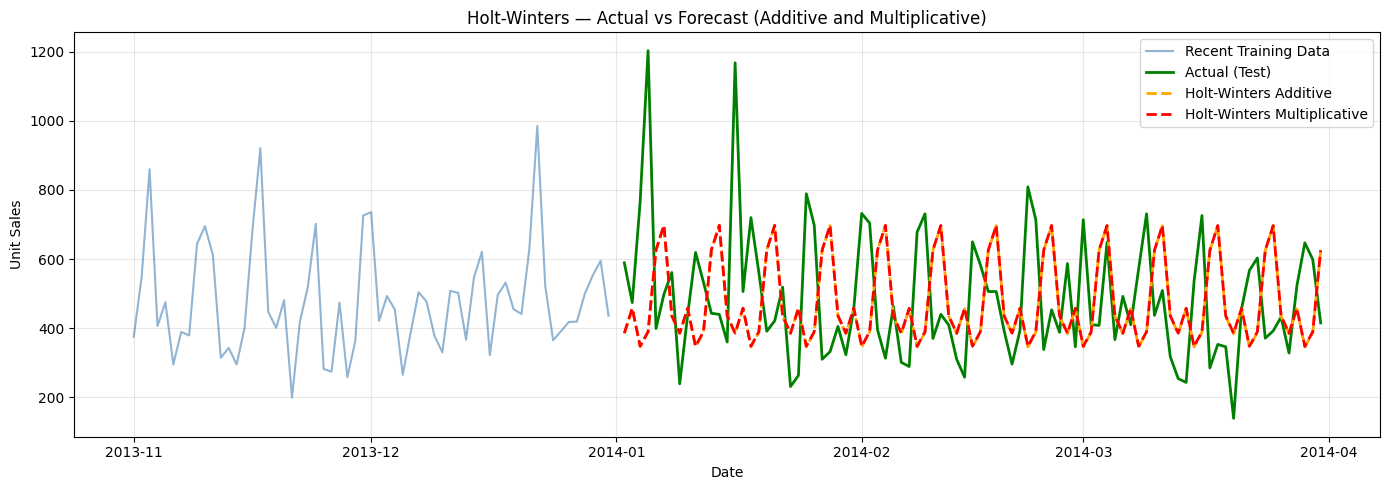

In [54]:
# Plot both Holt-Winters forecasts against actual values in one chart
plt.figure(figsize=(14, 5))

plt.plot(
    train.index[-60:],
    train["unit_sales"].iloc[-60:],
    label="Recent Training Data",
    color="steelblue",
    linewidth=1.5,
    alpha=0.6
)

plt.plot(
    test.index,
    test["unit_sales"],
    label="Actual (Test)",
    color="green",
    linewidth=2
)

plt.plot(
    forecast_hw_add.index,
    forecast_hw_add.values,
    label="Holt-Winters Additive",
    color="orange",
    linewidth=2,
    linestyle="--"
)

plt.plot(
    forecast_hw_mul.index,
    forecast_hw_mul.values,
    label="Holt-Winters Multiplicative",
    color="red",
    linewidth=2,
    linestyle="--"
)

plt.title("Holt-Winters — Actual vs Forecast (Additive and Multiplicative)")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [55]:
# Compare additive and multiplicative Holt-Winters forecasts numerically
hw_diff = (forecast_hw_add - forecast_hw_mul).abs()

print("Maximum absolute difference:", hw_diff.max())
print("Mean absolute difference:", hw_diff.mean())
print()

print("First 10 forecast differences:")
print(hw_diff.head(10))

Maximum absolute difference: 2.0838842886389557
Mean absolute difference: 1.2518965760439946

First 10 forecast differences:
date
2014-01-02    1.105009
2014-01-03    1.175417
2014-01-04    1.474502
2014-01-05    1.184545
2014-01-06    0.563138
2014-01-07    0.457552
2014-01-08    1.132860
2014-01-09    1.152483
2014-01-10    1.216592
2014-01-11    1.525284
dtype: float64


In [56]:
# Calculate evaluation metrics for both Holt-Winters models
mae_hw_add = mean_absolute_error(test["unit_sales"], forecast_hw_add)
rmse_hw_add = mean_squared_error(test["unit_sales"], forecast_hw_add) ** 0.5
r2_hw_add = r2_score(test["unit_sales"], forecast_hw_add)
mape_hw_add = mean_absolute_percentage_error(test["unit_sales"], forecast_hw_add)

mae_hw_mul = mean_absolute_error(test["unit_sales"], forecast_hw_mul)
rmse_hw_mul = mean_squared_error(test["unit_sales"], forecast_hw_mul) ** 0.5
r2_hw_mul = r2_score(test["unit_sales"], forecast_hw_mul)
mape_hw_mul = mean_absolute_percentage_error(test["unit_sales"], forecast_hw_mul)

print("Holt-Winters Additive — Evaluation Metrics:\n")
print(f"MAE   : {mae_hw_add:.2f}")
print(f"RMSE  : {rmse_hw_add:.2f}")
print(f"MAPE  : {mape_hw_add * 100:.2f} %")
print(f"R²    : {r2_hw_add:.3f}")

print("\n" + "-" * 40 + "\n")

print("Holt-Winters Multiplicative — Evaluation Metrics:\n")
print(f"MAE   : {mae_hw_mul:.2f}")
print(f"RMSE  : {rmse_hw_mul:.2f}")
print(f"MAPE  : {mape_hw_mul * 100:.2f} %")
print(f"R²    : {r2_hw_mul:.3f}")

Holt-Winters Additive — Evaluation Metrics:

MAE   : 206.54
RMSE  : 253.93
MAPE  : 44.16 %
R²    : -0.896

----------------------------------------

Holt-Winters Multiplicative — Evaluation Metrics:

MAE   : 206.54
RMSE  : 253.61
MAPE  : 44.25 %
R²    : -0.891


The additive and multiplicative Holt-Winters variants produced very similar forecasts and very similar evaluation metrics. In this dataset, the choice between additive and multiplicative seasonality has only a minor impact on performance.

# 13. Model 3 — Prophet

Prophet is a forecasting model developed for business time series with trend, seasonality, and holiday effects. It works differently from SARIMAX and Holt-Winters because it models the time series as a combination of interpretable components and requires a dataframe with two specific columns: `ds` for dates and `y` for the target values.

In [57]:
# Prepare the training and test datasets for Prophet
train_prophet = train.reset_index().iloc[:, :2].copy()
test_prophet = test.reset_index().iloc[:, :2].copy()

train_prophet.columns = ["ds", "y"]
test_prophet.columns = ["ds", "y"]

In [58]:
train_prophet.head(), test_prophet.head()

(          ds      y
 0 2013-01-02  582.0
 1 2013-01-03  310.0
 2 2013-01-04  338.0
 3 2013-01-05  654.0
 4 2013-01-06  979.0,
           ds       y
 0 2014-01-02   589.0
 1 2014-01-03   474.0
 2 2014-01-04   767.0
 3 2014-01-05  1203.0
 4 2014-01-06   399.0)

In [59]:
# Build a holiday dataframe for Prophet from the aligned exogenous dataframe
holiday_rows = []

for _, row in sarimax_exog_df.iterrows():
    if row["is_national_holiday"] == 1:
        holiday_rows.append({"holiday": "national_holiday", "ds": row["date"]})
    if row["is_regional_holiday"] == 1:
        holiday_rows.append({"holiday": "regional_holiday", "ds": row["date"]})
    if row["is_local_holiday"] == 1:
        holiday_rows.append({"holiday": "local_holiday", "ds": row["date"]})

holidays_prophet = pd.DataFrame(holiday_rows)

print("Holiday dataframe for Prophet:")
print(holidays_prophet.head(10))
print()
print("Total holiday dates passed to Prophet:", len(holidays_prophet))

Holiday dataframe for Prophet:
            holiday         ds
0  national_holiday 2013-01-05
1  national_holiday 2013-01-12
2  national_holiday 2013-02-11
3  national_holiday 2013-02-12
4     local_holiday 2013-03-02
5  regional_holiday 2013-04-01
6     local_holiday 2013-04-12
7     local_holiday 2013-04-14
8     local_holiday 2013-04-21
9  national_holiday 2013-04-29

Total holiday dates passed to Prophet: 50


In [62]:
# Fit the basic Prophet model
print("Fitting Basic Prophet model...")

model_prophet_basic = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=False,
    seasonality_mode="additive",
    holidays=holidays_prophet
)

model_prophet_basic.fit(train_prophet)

print("Basic Prophet fitted successfully!")

22:12:00 - cmdstanpy - INFO - Chain [1] start processing


Fitting Basic Prophet model...


22:12:00 - cmdstanpy - INFO - Chain [1] done processing


Basic Prophet fitted successfully!


In [64]:
# Advanced Prophet - adds oil price as an external regressor
# and uses a higher Fourier order for the weekly seasonality

print("Fitting Advanced Prophet model (with oil price regressor)...")

model_prophet_adv = Prophet(
    daily_seasonality=False,
    weekly_seasonality=False,
    yearly_seasonality=False,
    seasonality_mode="additive",
    holidays=holidays_prophet,
    changepoint_prior_scale=0.1
)

# Custom weekly seasonality with higher Fourier order
model_prophet_adv.add_seasonality(
    name="weekly_custom",
    period=7,
    fourier_order=5
)

# Add oil price as an external regressor
# Prophet will learn how much oil price movements affect sales
model_prophet_adv.add_regressor("dcoilwtico")

# Add training data WITH the oil regressor column included
prophet_train_adv = train_prophet.copy()
prophet_train_adv["dcoilwtico"] = exog_train["oil_price_interpolated"].values

model_prophet_adv.fit(prophet_train_adv)

print("Advanced Prophet fitted successfully!")

22:21:59 - cmdstanpy - INFO - Chain [1] start processing
22:21:59 - cmdstanpy - INFO - Chain [1] done processing


Fitting Advanced Prophet model (with oil price regressor)...
Advanced Prophet fitted successfully!


In [70]:
# Create future dataframe for basic model (history + test period)
future_basic = model_prophet_basic.make_future_dataframe(
    periods=len(test),
    freq="D"
)

forecast_basic = model_prophet_basic.predict(future_basic)

# Extract only the test-period predictions
prophet_basic_preds = forecast_basic.tail(len(test))["yhat"].values
prophet_basic_preds = prophet_basic_preds.clip(0)

print("Basic Prophet forecasts generated.")

Basic Prophet forecasts generated.


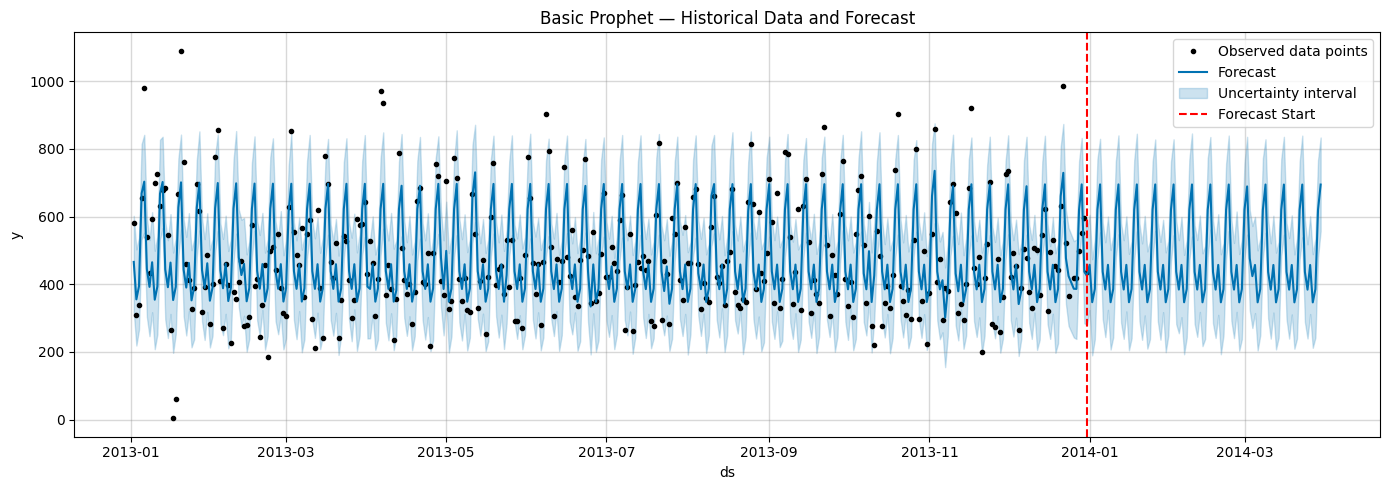

In [72]:
# Plot Prophet's built-in forecast chart (basic model)
fig = model_prophet_basic.plot(forecast_basic, figsize=(14, 5))
plt.title("Basic Prophet — Historical Data and Forecast")
plt.axvline(
    x=train_prophet["ds"].max(),
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Forecast Start"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [73]:
# Create future dataframe for advanced model (history + test period)
future_adv = model_prophet_adv.make_future_dataframe(
    periods=len(test),
    freq="D"
)

# Attach oil prices to all dates (train + test)
oil_full = pd.concat(
    [
        exog_train["oil_price_interpolated"],
        exog_test["oil_price_interpolated"]
    ],
    ignore_index=True
)

future_adv["dcoilwtico"] = oil_full.values

forecast_adv = model_prophet_adv.predict(future_adv)

# Extract only the test-period predictions
prophet_adv_preds = forecast_adv.tail(len(test))["yhat"].values
prophet_adv_preds = prophet_adv_preds.clip(0)

print("Advanced Prophet forecasts generated.")

Advanced Prophet forecasts generated.


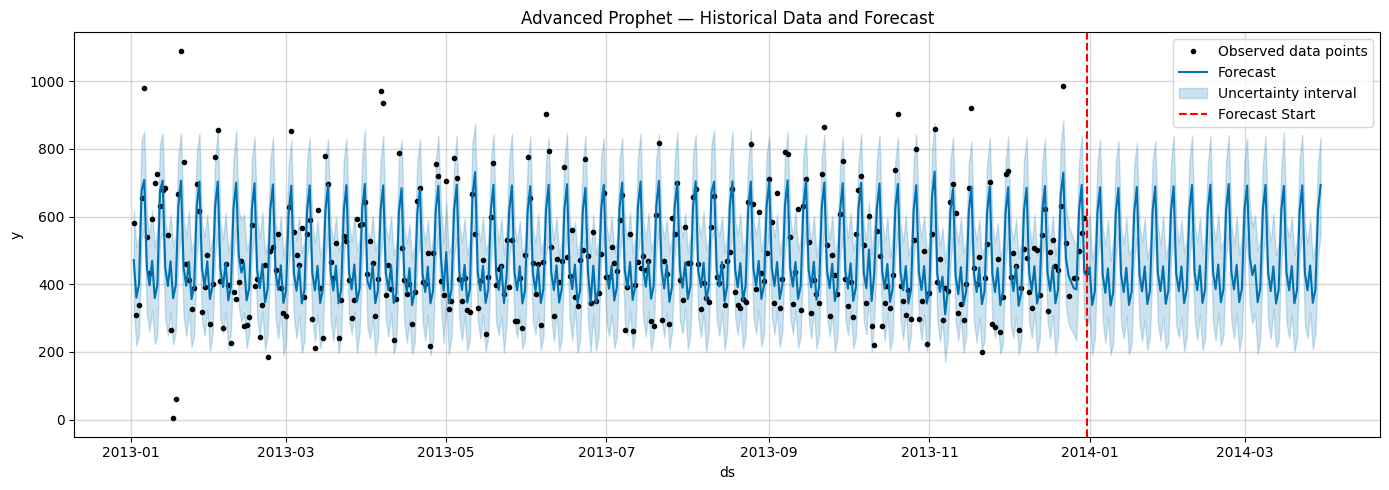

In [74]:
# Plot Prophet's built-in forecast chart (advanced model)
fig = model_prophet_adv.plot(forecast_adv, figsize=(14, 5))
plt.title("Advanced Prophet — Historical Data and Forecast")
plt.axvline(
    x=train_prophet["ds"].max(),
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Forecast Start"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [66]:
# Display the key forecast columns for both Prophet models
print("Basic Prophet forecast:")
print(forecast_prophet_basic[["ds", "yhat", "yhat_lower", "yhat_upper"]].head())
print()

print("Advanced Prophet forecast:")
print(forecast_prophet_adv[["ds", "yhat", "yhat_lower", "yhat_upper"]].head())

Basic Prophet forecast:
          ds        yhat  yhat_lower  yhat_upper
0 2014-01-02  347.090429  205.390751  487.002886
1 2014-01-03  386.201401  246.045383  518.438332
2 2014-01-04  620.789928  472.690737  773.252786
3 2014-01-05  695.135640  547.066814  837.502345
4 2014-01-06  437.144075  272.048702  587.671377

Advanced Prophet forecast:
          ds        yhat  yhat_lower  yhat_upper
0 2014-01-02  340.437204  191.069155  476.698226
1 2014-01-03  378.273568  234.395808  512.851925
2 2014-01-04  612.594994  463.098762  753.949405
3 2014-01-05  687.275595  550.496101  830.634063
4 2014-01-06  428.375506  288.564544  578.337456


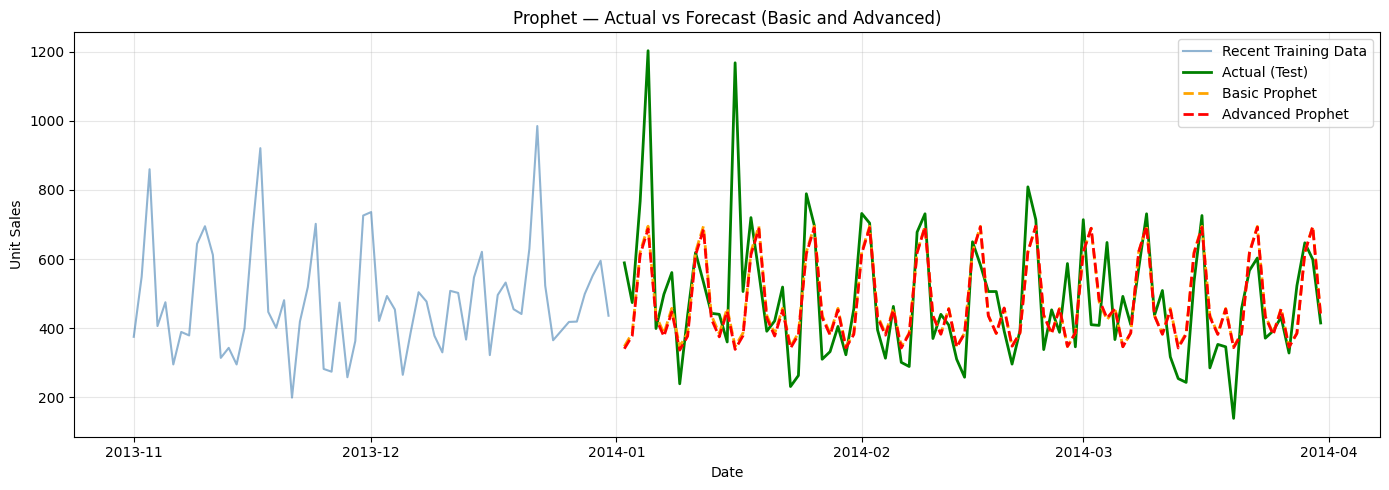

In [67]:
# Plot both Prophet forecasts against the actual test values
plt.figure(figsize=(14, 5))

plt.plot(
    train.index[-60:],
    train["unit_sales"].iloc[-60:],
    label="Recent Training Data",
    color="steelblue",
    linewidth=1.5,
    alpha=0.6
)

plt.plot(
    test.index,
    test["unit_sales"],
    label="Actual (Test)",
    color="green",
    linewidth=2
)

plt.plot(
    forecast_prophet_basic["ds"],
    forecast_prophet_basic["yhat"],
    label="Basic Prophet",
    color="orange",
    linewidth=2,
    linestyle="--"
)

plt.plot(
    forecast_prophet_adv["ds"],
    forecast_prophet_adv["yhat"],
    label="Advanced Prophet",
    color="red",
    linewidth=2,
    linestyle="--"
)

plt.title("Prophet — Actual vs Forecast (Basic and Advanced)")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [75]:
# Evaluate both Prophet variants
def score_prophet_model(name, actual, predictions):
    mae = mean_absolute_error(actual, predictions)
    rmse = mean_squared_error(actual, predictions) ** 0.5
    mape = mean_absolute_percentage_error(actual, predictions) * 100
    r2 = r2_score(actual, predictions)

    print(f"{name}:")
    print(f"  MAE : {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  R²  : {r2:.4f}")
    print()

    return mae, rmse, mape, r2


actual = test["unit_sales"].values

print("Prophet Evaluation Results:")
print()

basic_prophet_scores = score_prophet_model(
    "Basic Prophet",
    actual,
    prophet_basic_preds
)

advanced_prophet_scores = score_prophet_model(
    "Advanced Prophet",
    actual,
    prophet_adv_preds
)

Prophet Evaluation Results:

Basic Prophet:
  MAE : 165.23
  RMSE: 213.82
  MAPE: 37.43%
  R²  : -0.3441

Advanced Prophet:
  MAE : 165.37
  RMSE: 214.31
  MAPE: 37.25%
  R²  : -0.3503



The basic and advanced Prophet variants produced very similar results, with the basic version performing slightly better overall. This suggests that adding holidays and oil price as extra inputs did not improve forecast accuracy for this dataset. Compared with Holt-Winters, Prophet performs better, but it still remains weaker than the SARIMAX model.

# 14. Final Comparison of Statistical Models

In [76]:
# Collect all model scores into one comparison table

all_results = [
    {
        "Model": "SARIMAX + exogenous features",
        "MAE": mae_1,
        "RMSE": rmse_1,
        "MAPE": mape_1 * 100,
        "R2": r2_1
    },
    {
        "Model": "Holt-Winters Additive",
        "MAE": mae_hw_add,
        "RMSE": rmse_hw_add,
        "MAPE": mape_hw_add * 100,
        "R2": r2_hw_add
    },
    {
        "Model": "Holt-Winters Multiplicative",
        "MAE": mae_hw_mul,
        "RMSE": rmse_hw_mul,
        "MAPE": mape_hw_mul * 100,
        "R2": r2_hw_mul
    },
    {
        "Model": "Prophet Basic",
        "MAE": basic_prophet_scores[0],
        "RMSE": basic_prophet_scores[1],
        "MAPE": basic_prophet_scores[2],
        "R2": basic_prophet_scores[3]
    },
    {
        "Model": "Prophet Advanced",
        "MAE": advanced_prophet_scores[0],
        "RMSE": advanced_prophet_scores[1],
        "MAPE": advanced_prophet_scores[2],
        "R2": advanced_prophet_scores[3]
    }
]

results_df = pd.DataFrame(all_results)

results_df["MAE"] = results_df["MAE"].round(2)
results_df["RMSE"] = results_df["RMSE"].round(2)
results_df["MAPE"] = results_df["MAPE"].round(2)
results_df["R2"] = results_df["R2"].round(4)

print("Performance Comparison — All Statistical Models on the Same Test Set:")
print()
print(results_df.to_string(index=False))
print()

print("Best MAE :", results_df.loc[results_df["MAE"].idxmin(), "Model"])
print("Best RMSE:", results_df.loc[results_df["RMSE"].idxmin(), "Model"])
print("Best R2  :", results_df.loc[results_df["R2"].idxmax(), "Model"])

Performance Comparison — All Statistical Models on the Same Test Set:

                       Model    MAE   RMSE  MAPE      R2
SARIMAX + exogenous features  95.66 144.82 21.97  0.3835
       Holt-Winters Additive 206.54 253.93 44.16 -0.8957
 Holt-Winters Multiplicative 206.54 253.61 44.25 -0.8908
               Prophet Basic 165.23 213.82 37.43 -0.3441
            Prophet Advanced 165.37 214.31 37.25 -0.3503

Best MAE : SARIMAX + exogenous features
Best RMSE: SARIMAX + exogenous features
Best R2  : SARIMAX + exogenous features


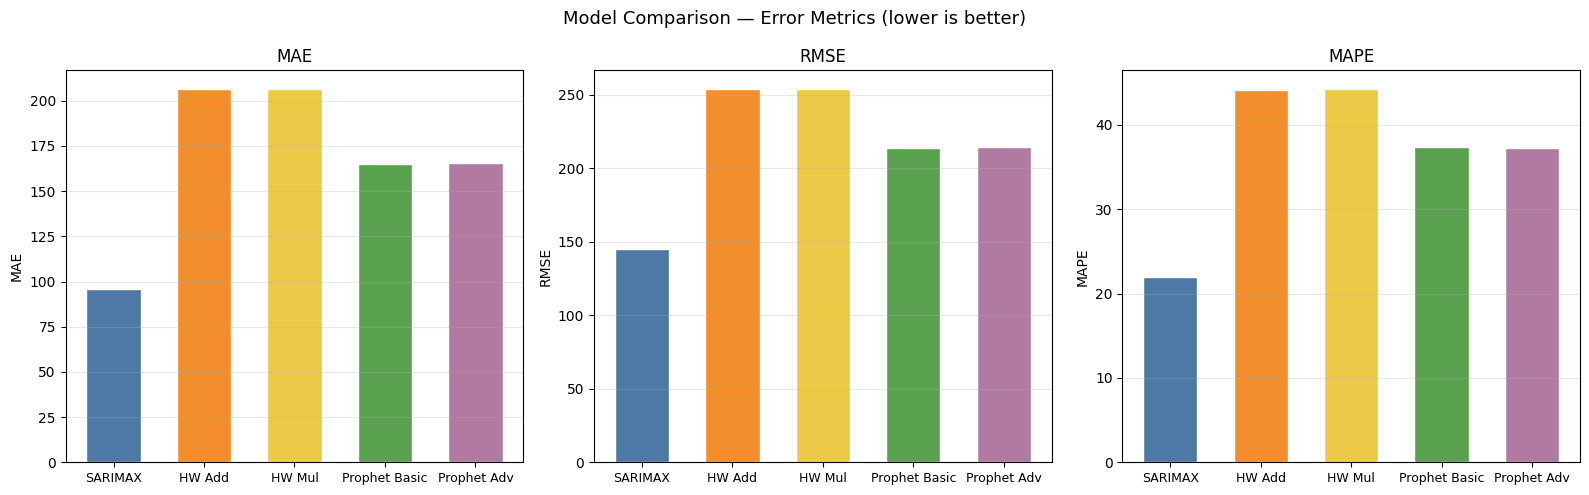

In [78]:
# Visualise the comparison with a grouped bar chart

metrics = ['MAE', 'RMSE', 'MAPE']
x = range(len(results_df))

model_colors = [
    '#4E79A7',  # SARIMAX
    '#F28E2B',  # HW Add
    '#EDC948',  # HW Mul
    '#59A14F',  # Prophet Basic
    '#B07AA1'   # Prophet Adv
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, metric in enumerate(metrics):
    axes[i].bar(
        x,
        results_df[metric],
        color=model_colors,
        edgecolor='white',
        width=0.6
    )
    axes[i].set_title(metric)
    axes[i].set_xticks(list(x))
    axes[i].set_xticklabels(
        ['SARIMAX', 'HW Add', 'HW Mul', 'Prophet Basic', 'Prophet Adv'],
        fontsize=9
    )
    axes[i].set_ylabel(metric)
    axes[i].grid(True, alpha=0.3, axis='y')

plt.suptitle('Model Comparison — Error Metrics (lower is better)', fontsize=13)
plt.tight_layout()
plt.show()

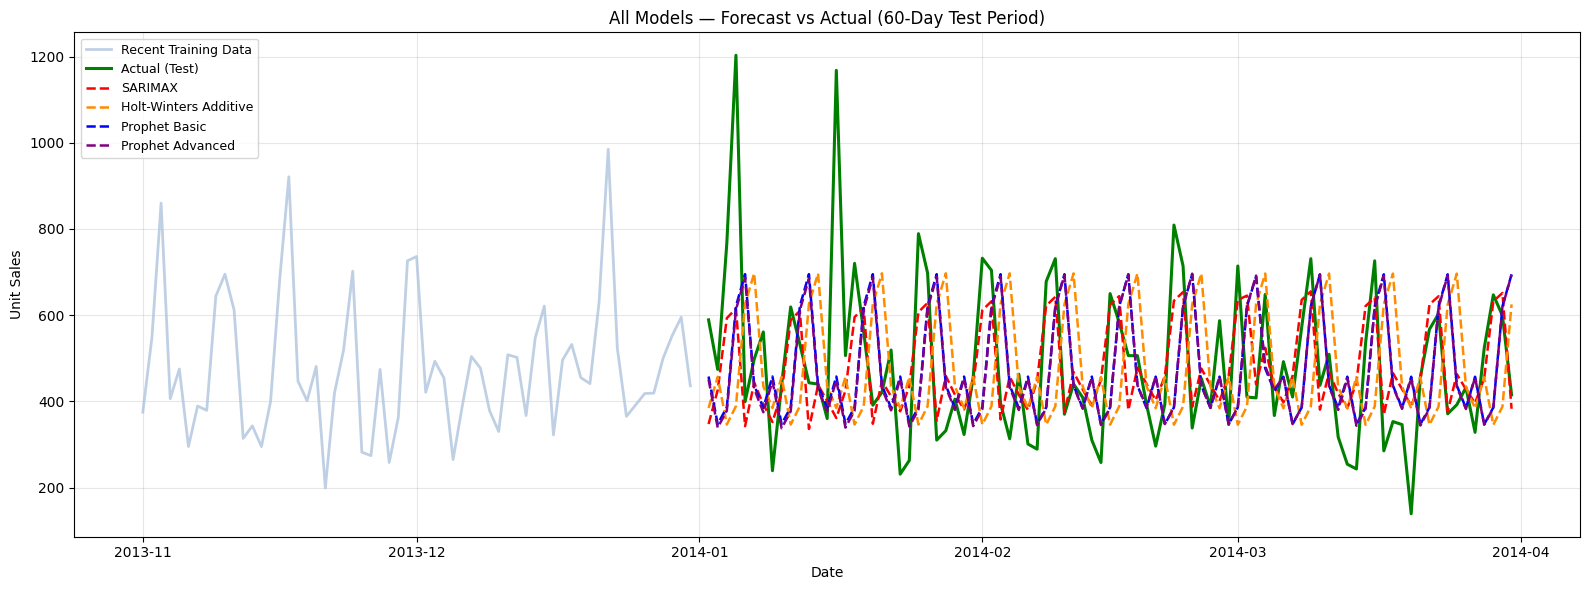

In [81]:
# Plot all forecasts on one chart for visual comparison

plt.figure(figsize=(16, 6))

plt.plot(
    train.index[-60:],
    train["unit_sales"].iloc[-60:],
    label="Recent Training Data",
    color="lightsteelblue",
    linewidth=2,
    alpha=0.8
)

plt.plot(
    test.index,
    test["unit_sales"],
    label="Actual (Test)",
    color="green",
    linewidth=2.2
)

plt.plot(
    test.index,
    forecast_1.values,
    label="SARIMAX",
    color="red",
    linewidth=1.8,
    linestyle="--"
)

plt.plot(
    test.index,
    forecast_hw_add.values,
    label="Holt-Winters Additive",
    color="darkorange",
    linewidth=1.8,
    linestyle="--"
)

plt.plot(
    test.index,
    prophet_basic_preds,
    label="Prophet Basic",
    color="blue",
    linewidth=1.8,
    linestyle="--"
)

plt.plot(
    test.index,
    prophet_adv_preds,
    label="Prophet Advanced",
    color="purple",
    linewidth=1.8,
    linestyle="--"
)

plt.title("All Models — Forecast vs Actual (60-Day Test Period)")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend(loc="upper left", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

SARIMAX achieved the best overall performance across all evaluation metrics and was the strongest statistical model on the 60-day test period. Holt-Winters performed worst, showing that simple seasonal smoothing was not sufficient for this dataset. Prophet outperformed Holt-Winters but still remained weaker than SARIMAX. Overall, the results suggest that combining autoregressive structure, seasonality, and exogenous features provides the most effective statistical forecasting approach for this sales series.